# Specific Task 4: Non-local GNNs for Jet Classification

Comparing local and non-local graph neural networks for quark/gluon jet classification. We evaluate three architectures on identical data and training conditions:

1. **Baseline EdgeConv** — local message passing only (k=7 neighbors)
2. **EdgeConv + Self-Attention** — local message passing augmented with global self-attention after each layer
3. **Graph Transformer** — multi-head attention-based message passing (TransformerConv)

The only architectural difference between the baseline and non-local variants is how information propagates: locally through edges vs globally across all nodes in the jet.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup and Graph Construction

In [ ]:
!pip install torch-geometric -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import gc
import time
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.nn import EdgeConv, TransformerConv, global_mean_pool, global_max_pool
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.neighbors import NearestNeighbors

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

filepath = '/content/drive/MyDrive/quark-gluon_data-set_n139306.hdf5'

N_EVENTS = 20000
MAX_NODES = 150
K = 7

with h5py.File(filepath, 'r') as f:
    X_raw = f['X_jets'][:N_EVENTS].astype('float32')
    y_raw = f['y'][:N_EVENTS].astype('int64')
print(f"Loaded: {X_raw.shape}, labels: {np.unique(y_raw, return_counts=True)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.9 MB/s eta 0:00:00
Device: cuda
Loaded: (20000, 125, 125, 3), labels: (array([0, 1]), array([ 9995, 10005]))


Each 125×125×3 jet image is converted to a graph:
- **Nodes**: non-zero pixels (capped at 150, keeping highest-energy hits, zero-padded if fewer)
- **Features**: η, φ coordinates + log-transformed ECAL, HCAL, Track, and total energy (6 dims)
- **Edges**: k=7 nearest neighbors in (η, φ) space

In [ ]:
def image_to_graph(img, label, max_nodes=MAX_NODES, k=K):
    ecal, hcal, tracks = img[:,:,0], img[:,:,1], img[:,:,2]
    mask = (ecal > 0) | (hcal > 0) | (tracks > 0)
    eta_idx, phi_idx = np.where(mask)

    if len(eta_idx) < 3:
        return None

    e = ecal[eta_idx, phi_idx]
    h = hcal[eta_idx, phi_idx]
    t = tracks[eta_idx, phi_idx]
    total = e + h + t

    if len(eta_idx) > max_nodes:
        top = np.argsort(total)[-max_nodes:]
        eta_idx, phi_idx = eta_idx[top], phi_idx[top]
        e, h, t, total = e[top], h[top], t[top], total[top]

    n = len(eta_idx)
    if n < max_nodes:
        pad = max_nodes - n
        eta_idx = np.pad(eta_idx, (0, pad), constant_values=62)
        phi_idx = np.pad(phi_idx, (0, pad), constant_values=62)
        e = np.pad(e, (0, pad))
        h = np.pad(h, (0, pad))
        t = np.pad(t, (0, pad))
        total = np.pad(total, (0, pad))

    eta = (eta_idx / 124.0) * 2 - 1
    phi = (phi_idx / 124.0) * 2 - 1
    features = np.stack([
        eta, phi,
        np.log1p(e * 1000), np.log1p(h * 1000),
        np.log1p(t * 1000), np.log1p(total * 1000)
    ], axis=1).astype(np.float32)

    coords = np.stack([eta, phi], axis=1)
    k_actual = min(k, len(eta) - 1)
    nn_model = NearestNeighbors(n_neighbors=k_actual + 1)
    nn_model.fit(coords)
    _, indices = nn_model.kneighbors(coords)
    src = np.repeat(np.arange(len(eta)), k_actual)
    dst = indices[:, 1:].flatten()
    edge_index = np.stack([src, dst], axis=0)

    return Data(
        x=torch.tensor(features),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        y=torch.tensor([label], dtype=torch.long),
    )

print("Building graphs...")
graphs = []
for i in range(N_EVENTS):
    g = image_to_graph(X_raw[i], y_raw[i])
    if g is not None:
        graphs.append(g)
    if (i + 1) % 5000 == 0:
        print(f"  {i+1}/{N_EVENTS}")

del X_raw, y_raw
gc.collect()
print(f"Total graphs: {len(graphs)}")

all_feats = torch.cat([g.x for g in graphs], dim=0)
feat_mean = all_feats.mean(0)
feat_std = all_feats.std(0)
feat_std[feat_std == 0] = 1.0
for g in graphs:
    g.x = (g.x - feat_mean) / feat_std
del all_feats
gc.collect()

train_g, test_g = train_test_split(graphs, test_size=0.15, random_state=42)
train_g, val_g = train_test_split(train_g, test_size=0.176, random_state=42)
print(f"Train: {len(train_g)}, Val: {len(val_g)}, Test: {len(test_g)}")

train_loader = GeoDataLoader(train_g, batch_size=128, shuffle=True)
val_loader = GeoDataLoader(val_g, batch_size=128, shuffle=False)
test_loader = GeoDataLoader(test_g, batch_size=128, shuffle=False)

Building graphs...
  5000/20000
  10000/20000
  15000/20000
  20000/20000
Total graphs: 20000
Train: 14008, Val: 2992, Test: 3000


## Model Definitions

### Baseline: Local EdgeConv
Standard 3-layer EdgeConv with max aggregation. Each node only communicates with its k=7 spatial neighbors.

### Non-local: EdgeConv + Self-Attention
Same EdgeConv backbone, but after each message passing layer, a multi-head self-attention block allows every node to attend to every other node in the jet. This introduces non-local information flow while preserving the local inductive bias from EdgeConv.

### Graph Transformer
Replaces EdgeConv entirely with TransformerConv, which uses multi-head attention for message passing along edges.

In [ ]:
class BaselineEdgeConv(nn.Module):
    def __init__(self, in_dim=6):
        super().__init__()
        self.conv1 = EdgeConv(Sequential(
            Linear(2 * in_dim, 64), BatchNorm1d(64), ReLU(),
            Linear(64, 64), BatchNorm1d(64), ReLU()), aggr='max')
        self.conv2 = EdgeConv(Sequential(
            Linear(2 * 64, 128), BatchNorm1d(128), ReLU(),
            Linear(128, 128), BatchNorm1d(128), ReLU()), aggr='max')
        self.conv3 = EdgeConv(Sequential(
            Linear(2 * 128, 256), BatchNorm1d(256), ReLU(),
            Linear(256, 256), BatchNorm1d(256), ReLU()), aggr='max')
        self.classifier = Sequential(
            Linear(512, 256), BatchNorm1d(256), ReLU(), nn.Dropout(0.5),
            Linear(256, 64), BatchNorm1d(64), ReLU(), nn.Dropout(0.5),
            Linear(64, 2))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)


class SelfAttentionBlock(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, batch, num_nodes=MAX_NODES):
        batch_size = batch.max().item() + 1
        x_batched = x.view(batch_size, num_nodes, -1)
        attn_out, _ = self.attn(x_batched, x_batched, x_batched)
        x_batched = self.norm(x_batched + self.dropout(attn_out))
        return x_batched.view(-1, x.size(-1))


class NonLocalEdgeConv(nn.Module):
    def __init__(self, in_dim=6):
        super().__init__()
        self.conv1 = EdgeConv(Sequential(
            Linear(2 * in_dim, 64), BatchNorm1d(64), ReLU(),
            Linear(64, 64), BatchNorm1d(64), ReLU()), aggr='max')
        self.conv2 = EdgeConv(Sequential(
            Linear(2 * 64, 128), BatchNorm1d(128), ReLU(),
            Linear(128, 128), BatchNorm1d(128), ReLU()), aggr='max')
        self.conv3 = EdgeConv(Sequential(
            Linear(2 * 128, 256), BatchNorm1d(256), ReLU(),
            Linear(256, 256), BatchNorm1d(256), ReLU()), aggr='max')
        self.attn1 = SelfAttentionBlock(64, heads=4, dropout=0.1)
        self.attn2 = SelfAttentionBlock(128, heads=4, dropout=0.1)
        self.attn3 = SelfAttentionBlock(256, heads=4, dropout=0.1)
        self.classifier = Sequential(
            Linear(512, 256), BatchNorm1d(256), ReLU(), nn.Dropout(0.5),
            Linear(256, 64), BatchNorm1d(64), ReLU(), nn.Dropout(0.5),
            Linear(64, 2))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.attn1(x, batch)
        x = self.conv2(x, edge_index)
        x = self.attn2(x, batch)
        x = self.conv3(x, edge_index)
        x = self.attn3(x, batch)
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)


class GraphTransformerNet(nn.Module):
    def __init__(self, in_dim=6):
        super().__init__()
        self.embed = Linear(in_dim, 64)
        self.conv1 = TransformerConv(64, 32, heads=4, concat=True, dropout=0.3)
        self.bn1 = BatchNorm1d(128)
        self.conv2 = TransformerConv(128, 32, heads=4, concat=True, dropout=0.3)
        self.bn2 = BatchNorm1d(128)
        self.conv3 = TransformerConv(128, 64, heads=4, concat=True, dropout=0.3)
        self.bn3 = BatchNorm1d(256)
        self.classifier = Sequential(
            Linear(512, 256), BatchNorm1d(256), ReLU(), nn.Dropout(0.5),
            Linear(256, 64), BatchNorm1d(64), ReLU(), nn.Dropout(0.5),
            Linear(64, 2))

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.embed(x))
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = torch.cat([global_mean_pool(x, batch), global_max_pool(x, batch)], dim=1)
        return self.classifier(x)

## Training

All three models are trained with identical settings: AdamW optimizer (lr=5e-4, weight decay=1e-2), cross-entropy loss with label smoothing (0.1), gradient clipping at 0.5, for 10 epochs. The best checkpoint by validation accuracy is saved and used for test evaluation.

In [ ]:
def train_and_evaluate(model, name, epochs=10):
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        tl, tc, tt = 0, 0, 0
        for batch in train_loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y.view(-1))
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            tl += loss.item() * batch.num_graphs
            tc += (out.argmax(1) == batch.y.view(-1)).sum().item()
            tt += batch.num_graphs

        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                out = model(batch)
                vl += criterion(out, batch.y.view(-1)).item() * batch.num_graphs
                vc += (out.argmax(1) == batch.y.view(-1)).sum().item()
                vt += batch.num_graphs

        tl /= tt; ta = tc / tt; vl /= vt; va = vc / vt
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta); val_accs.append(va)

        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), f'best_{name}.pt')

        dt = time.time() - t0
        print(f"  Epoch {epoch+1:02d}/{epochs} — loss: {tl:.4f}/{vl:.4f}, "
              f"acc: {ta:.4f}/{va:.4f}, time: {dt:.1f}s")

    print(f"  Best val acc: {best_val_acc:.4f}")

    model.load_state_dict(torch.load(f'best_{name}.pt'))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            out = model(batch)
            all_preds.append(out.argmax(1).cpu())
            all_labels.append(batch.y.view(-1).cpu())
            all_probs.append(F.softmax(out, dim=1)[:, 1].cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    acc = (all_preds == all_labels).mean()
    auc = roc_auc_score(all_labels, all_probs)
    print(f"  Test Accuracy: {acc:.4f}, Test AUC: {auc:.4f}\n")
    return all_labels, all_probs, train_losses, val_losses, train_accs, val_accs

In [ ]:
print("=" * 50)
print("1/3  BASELINE: Local EdgeConv")
print("=" * 50)
baseline = BaselineEdgeConv(in_dim=6).to(device)
print(f"Parameters: {sum(p.numel() for p in baseline.parameters()):,}")
b_labels, b_probs, b_tl, b_vl, b_ta, b_va = train_and_evaluate(baseline, 'baseline')

print("=" * 50)
print("2/3  NON-LOCAL: EdgeConv + Self-Attention")
print("=" * 50)
nonlocal_model = NonLocalEdgeConv(in_dim=6).to(device)
print(f"Parameters: {sum(p.numel() for p in nonlocal_model.parameters()):,}")
nl_labels, nl_probs, nl_tl, nl_vl, nl_ta, nl_va = train_and_evaluate(nonlocal_model, 'nonlocal')

print("=" * 50)
print("3/3  GRAPH TRANSFORMER: TransformerConv")
print("=" * 50)
gt_model = GraphTransformerNet(in_dim=6).to(device)
print(f"Parameters: {sum(p.numel() for p in gt_model.parameters()):,}")
gt_labels, gt_probs, gt_tl, gt_vl, gt_ta, gt_va = train_and_evaluate(gt_model, 'transformer')

1/3  BASELINE: Local EdgeConv
Parameters: 319,938


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


  Epoch 01/10 — loss: 0.6458/0.5958, acc: 0.6714/0.7149, time: 15.7s
  Epoch 02/10 — loss: 0.6061/0.6118, acc: 0.7065/0.6842, time: 12.2s
  Epoch 03/10 — loss: 0.5936/0.5934, acc: 0.7196/0.7236, time: 11.7s
  Epoch 04/10 — loss: 0.5877/0.5904, acc: 0.7245/0.7269, time: 11.8s
  Epoch 05/10 — loss: 0.5817/0.5944, acc: 0.7339/0.7196, time: 12.0s
  Epoch 06/10 — loss: 0.5770/0.5992, acc: 0.7383/0.7102, time: 12.0s
  Epoch 07/10 — loss: 0.5675/0.5987, acc: 0.7424/0.7106, time: 12.2s
  Epoch 08/10 — loss: 0.5598/0.6100, acc: 0.7528/0.7102, time: 12.3s
  Epoch 09/10 — loss: 0.5487/0.6726, acc: 0.7618/0.6661, time: 12.8s
  Epoch 10/10 — loss: 0.5363/0.6358, acc: 0.7731/0.6865, time: 12.7s
  Best val acc: 0.7269
  Test Accuracy: 0.7223, Test AUC: 0.7906

2/3  NON-LOCAL: EdgeConv + Self-Attention
Parameters: 666,690


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


  Epoch 01/10 — loss: 0.6401/0.6140, acc: 0.6638/0.7062, time: 18.1s
  Epoch 02/10 — loss: 0.6018/0.5942, acc: 0.7126/0.7203, time: 17.7s
  Epoch 03/10 — loss: 0.5931/0.6011, acc: 0.7212/0.7129, time: 17.7s
  Epoch 04/10 — loss: 0.5846/0.6007, acc: 0.7267/0.7129, time: 17.7s
  Epoch 05/10 — loss: 0.5805/0.5917, acc: 0.7359/0.7216, time: 17.9s
  Epoch 06/10 — loss: 0.5778/0.5921, acc: 0.7339/0.7182, time: 17.9s
  Epoch 07/10 — loss: 0.5733/0.6030, acc: 0.7406/0.7002, time: 17.9s
  Epoch 08/10 — loss: 0.5699/0.5956, acc: 0.7418/0.7139, time: 17.8s
  Epoch 09/10 — loss: 0.5651/0.6076, acc: 0.7471/0.6969, time: 17.8s
  Epoch 10/10 — loss: 0.5566/0.5973, acc: 0.7544/0.7219, time: 17.9s
  Best val acc: 0.7219
  Test Accuracy: 0.7243, Test AUC: 0.7841

3/3  GRAPH TRANSFORMER: TransformerConv
Parameters: 381,442


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


  Epoch 01/10 — loss: 0.6396/0.6208, acc: 0.6704/0.6748, time: 7.7s
  Epoch 02/10 — loss: 0.6066/0.6177, acc: 0.7055/0.6895, time: 7.8s
  Epoch 03/10 — loss: 0.5923/0.5926, acc: 0.7219/0.7199, time: 7.7s
  Epoch 04/10 — loss: 0.5896/0.5917, acc: 0.7244/0.7213, time: 7.8s
  Epoch 05/10 — loss: 0.5858/0.6199, acc: 0.7276/0.6745, time: 7.8s
  Epoch 06/10 — loss: 0.5824/0.5896, acc: 0.7307/0.7229, time: 7.7s
  Epoch 07/10 — loss: 0.5826/0.6133, acc: 0.7318/0.6915, time: 7.8s
  Epoch 08/10 — loss: 0.5797/0.5897, acc: 0.7341/0.7206, time: 7.7s
  Epoch 09/10 — loss: 0.5783/0.5911, acc: 0.7332/0.7189, time: 7.9s
  Epoch 10/10 — loss: 0.5758/0.6272, acc: 0.7367/0.6715, time: 7.7s
  Best val acc: 0.7229
  Test Accuracy: 0.7230, Test AUC: 0.7943



## Results

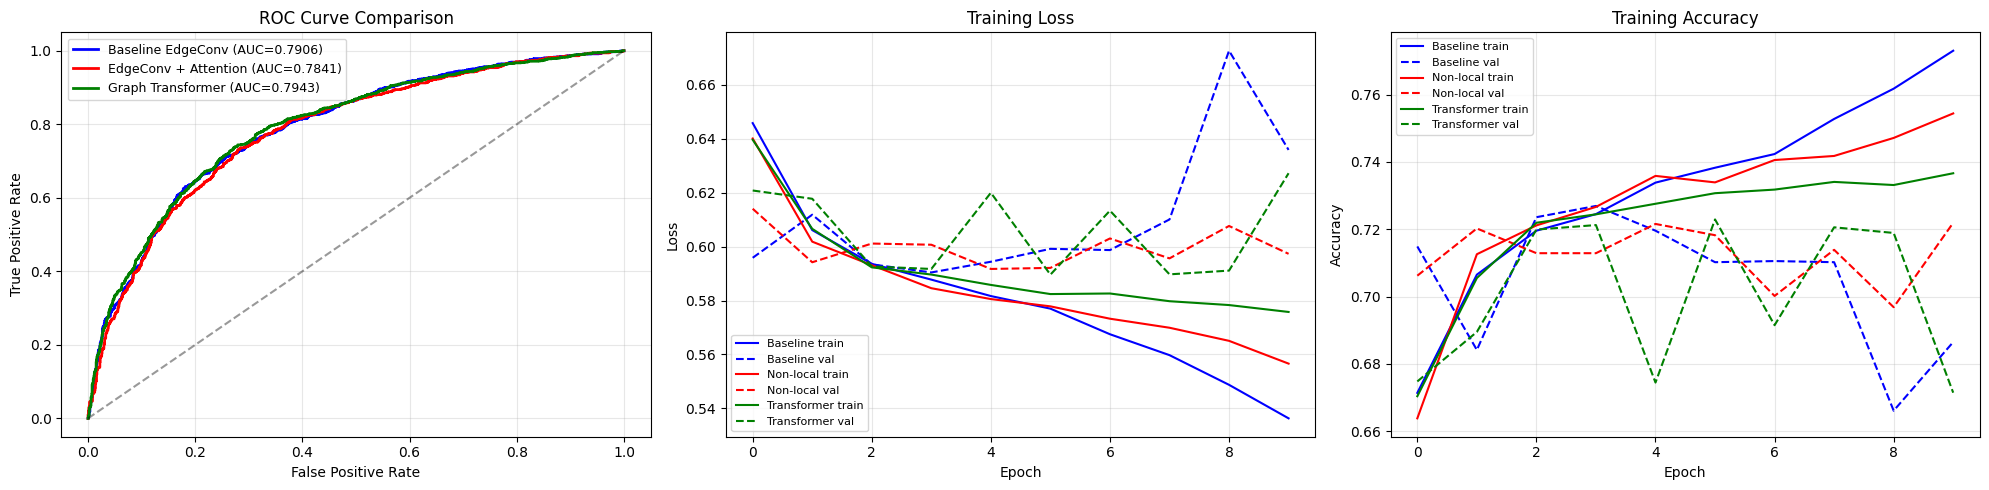


Model                               AUC      Acc     Params
Baseline EdgeConv                0.7906   72.2%    319,938
EdgeConv + Attention             0.7841   72.4%    666,690
Graph Transformer                0.7943   72.3%    381,442


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
for name, labels, probs, style in [
    ('Baseline EdgeConv', b_labels, b_probs, 'b-'),
    ('EdgeConv + Attention', nl_labels, nl_probs, 'r-'),
    ('Graph Transformer', gt_labels, gt_probs, 'g-')]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, style, linewidth=2, label=f'{name} (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(b_tl, 'b-', label='Baseline train')
ax.plot(b_vl, 'b--', label='Baseline val')
ax.plot(nl_tl, 'r-', label='Non-local train')
ax.plot(nl_vl, 'r--', label='Non-local val')
ax.plot(gt_tl, 'g-', label='Transformer train')
ax.plot(gt_vl, 'g--', label='Transformer val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(b_ta, 'b-', label='Baseline train')
ax.plot(b_va, 'b--', label='Baseline val')
ax.plot(nl_ta, 'r-', label='Non-local train')
ax.plot(nl_va, 'r--', label='Non-local val')
ax.plot(gt_ta, 'g-', label='Transformer train')
ax.plot(gt_va, 'g--', label='Transformer val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(f"{'Model':<30} {'AUC':>8} {'Acc':>8} {'Params':>10}")
print("=" * 60)
for name, labels, probs, model in [
    ('Baseline EdgeConv', b_labels, b_probs, baseline),
    ('EdgeConv + Attention', nl_labels, nl_probs, nonlocal_model),
    ('Graph Transformer', gt_labels, gt_probs, gt_model)]:
    auc = roc_auc_score(labels, probs)
    acc = (labels == (probs > 0.5).astype(int)).mean()
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:<30} {auc:>8.4f} {acc:>7.1%} {params:>10,}")
print("=" * 60)

## Discussion

**Summary of results:**

| Model | Test AUC | Test Acc | Parameters |
|-------|----------|----------|------------|
| Baseline EdgeConv (local) | 0.7906 | 72.2% | 320K |
| EdgeConv + Self-Attention (non-local) | 0.7841 | 72.4% | 667K |
| Graph Transformer (non-local) | 0.7943 | 72.3% | 381K |

All three models perform within a narrow AUC band of 0.784–0.794, with the Graph Transformer achieving the highest AUC (0.7943).

**Local vs non-local:** The Graph Transformer, which uses attention-based message passing (TransformerConv), slightly outperforms the purely local EdgeConv baseline by AUC. This suggests that attention-weighted neighbor aggregation — where the model learns which neighbors matter most — provides a modest advantage over the fixed max-aggregation in EdgeConv. The EdgeConv + Self-Attention hybrid did not consistently outperform the baseline, possibly because the added global attention over padded 150-node graphs introduces noise from artificial zero-padded nodes that dilutes the attention signal.
